In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

## 1. Convert CSV to Qlib Format

In [2]:
from alpha_model.qlib_integration import convert_csv_to_qlib, QLIB_DATA_DIR
from pathlib import Path

# ============================================
# CONFIGURE YOUR PERSONAL DATA PATH HERE
# ============================================      
CSV_DATA_DIR = "../data/historical"  # Change this to your CSV data directory

# Verify source directory exists
csv_path = Path(CSV_DATA_DIR)
if csv_path.exists():
    csv_files = list(csv_path.glob("*.csv"))
    print(f"Found {len(csv_files)} CSV files in: {csv_path.resolve()}")
    if csv_files:
        print(f"Sample files: {[f.name for f in csv_files[:5]]}")
else:
    print(f"⚠ Directory not found: {csv_path.resolve()}")
    print("Please update CSV_DATA_DIR to point to your data folder")

# Convert CSV data to Qlib binary format
convert_csv_to_qlib(csv_dir=CSV_DATA_DIR)

# Verify output
qlib_path = Path(QLIB_DATA_DIR).expanduser()
if qlib_path.exists():
    instruments = list(qlib_path.glob("*"))
    print(f"\n✓ Qlib data created at: {qlib_path}")
    print(f"  Instruments converted: {len([d for d in instruments if d.is_dir()])}")

Found 10 CSV files in: D:\THUCHANH\CF\data\historical
Sample files: ['ACB_ohlc.csv', 'BID_ohlc.csv', 'HPG_ohlc.csv', 'MSN_ohlc.csv', 'MWG_ohlc.csv']
  Read: acb (4737 rows)
  Read: bid (2956 rows)
  Read: hpg (4500 rows)
  Read: msn (4011 rows)
  Read: mwg (2846 rows)
  Read: vcb (4101 rows)
  Read: vhm (1888 rows)
  Read: vic (4541 rows)
  Read: vnm (4955 rows)
  Read: vpb (2071 rows)
  Calendar: 4958 days
  ✓ acb
  ✓ bid
  ✓ hpg
  ✓ msn
  ✓ mwg
  ✓ vcb
  ✓ vhm
  ✓ vic
  ✓ vnm
  ✓ vpb

✓ Converted 10 symbols to Qlib format
  Output: C:\Users\Ngoc\.qlib\qlib_data\vn_data

✓ Qlib data created at: C:\Users\Ngoc\.qlib\qlib_data\vn_data
  Instruments converted: 3


## 2. Initialize Qlib

In [3]:
import qlib
from qlib.config import REG_CN

# Initialize Qlib with Vietnamese data
qlib_path = Path(QLIB_DATA_DIR).expanduser()
qlib.init(provider_uri=str(qlib_path), region=REG_CN)
print(f"✓ Qlib initialized: {qlib_path}")

[19396:MainThread](2025-12-05 19:31:08,490) INFO - qlib.Initialization - [config.py:452] - default_conf: client.
[19396:MainThread](2025-12-05 19:31:09,695) INFO - qlib.Initialization - [__init__.py:75] - qlib successfully initialized based on client settings.
[19396:MainThread](2025-12-05 19:31:09,696) INFO - qlib.Initialization - [__init__.py:77] - data_path={'__DEFAULT_FREQ': WindowsPath('C:/Users/Ngoc/.qlib/qlib_data/vn_data')}


✓ Qlib initialized: C:\Users\Ngoc\.qlib\qlib_data\vn_data


## 3. Load Data & Check

In [4]:
from qlib.data import D

# List available instruments
instruments = D.instruments(market='all')
print(f"Available instruments: {instruments}")

# Get features for one stock
df = D.features(
    instruments=['vnm'],
    fields=['$close', '$volume', '$high', '$low', '$open'],
    start_time='2020-01-01',
    end_time='2023-12-31'
)
print(f"\nData shape: {df.shape}")
df.head(10)

Available instruments: {'market': 'all', 'filter_pipe': []}

Data shape: (1000, 5)


$close   $volume       $high        $low  \
instrument datetime                                                   
vnm        2020-01-02  117.900002  352700.0  118.199997  116.500000   
           2020-01-03  118.300003  625390.0  119.000000  118.199997   
           2020-01-06  117.400002  495910.0  118.199997  116.800003   
           2020-01-07  118.500000  459520.0  118.800003  117.500000   
           2020-01-08  118.800003  837710.0  118.800003  117.500000   
           2020-01-09  118.599998  624130.0  119.500000  118.400002   
           2020-01-10  118.900002  596280.0  119.199997  118.400002   
           2020-01-13  117.400002  412880.0  119.000000  117.400002   
           2020-01-14  117.800003  335180.0  118.099998  117.099998   
           2020-01-15  117.800003  681740.0  117.900002  117.199997   

                            $open  
instrument datetime                
vnm        2020-01-02  117.000000  
           2020-01-03  118.199997  
           2020-01-06  118.000000  
           2020-01-07  117.500000  
           2020-01-08  118.500000  
           2020-01-09  119.000000  
           2020-01-10  118.599998  
           2020-01-13  119.000000  
           2020-01-14  117.400002  
           2020-01-15  117.800003

## 4. Create Dataset with Alpha158 Features

In [9]:
from qlib.data.dataset import DatasetH
from qlib.contrib.data.handler import Alpha158

# Define time periods - adjusted to match data availability
TRAIN_START = "2020-01-01"
TRAIN_END = "2022-12-31"
VALID_START = "2023-01-01"
VALID_END = "2023-06-30"
TEST_START = "2023-07-01"
TEST_END = "2023-12-31"

# Use built-in Alpha158 handler
handler = Alpha158(
    instruments="all",
    start_time=TRAIN_START,
    end_time=TEST_END,
)

# Create dataset
dataset = DatasetH(
    handler=handler,
    segments={
        "train": (TRAIN_START, TRAIN_END),
        "valid": (VALID_START, VALID_END),
        "test": (TEST_START, TEST_END),
    }
)

print(f"✓ Dataset created with Alpha158 (158 built-in factors)")
print(f"  Train: {TRAIN_START} to {TRAIN_END}")
print(f"  Valid: {VALID_START} to {VALID_END}")
print(f"  Test:  {TEST_START} to {TEST_END}")

[19396:MainThread](2025-12-05 19:37:01,423) INFO - qlib.timer - [log.py:127] - Time cost: 24.291s | Loading data Done
[19396:MainThread](2025-12-05 19:37:01,449) INFO - qlib.timer - [log.py:127] - Time cost: 0.014s | DropnaLabel Done
[19396:MainThread](2025-12-05 19:37:01,449) INFO - qlib.timer - [log.py:127] - Time cost: 0.014s | DropnaLabel Done
[19396:MainThread](2025-12-05 19:37:02,309) INFO - qlib.timer - [log.py:127] - Time cost: 0.859s | CSZScoreNorm Done
[19396:MainThread](2025-12-05 19:37:02,311) INFO - qlib.timer - [log.py:127] - Time cost: 0.886s | fit & process data Done
[19396:MainThread](2025-12-05 19:37:02,311) INFO - qlib.timer - [log.py:127] - Time cost: 25.179s | Init data Done
[19396:MainThread](2025-12-05 19:37:02,309) INFO - qlib.timer - [log.py:127] - Time cost: 0.859s | CSZScoreNorm Done
[19396:MainThread](2025-12-05 19:37:02,311) INFO - qlib.timer - [log.py:127] - Time cost: 0.886s | fit & process data Done
[19396:MainThread](2025-12-05 19:37:02,311) INFO - qlib

✓ Dataset created with Alpha158 (158 built-in factors)
  Train: 2020-01-01 to 2022-12-31
  Valid: 2023-01-01 to 2023-06-30
  Test:  2023-07-01 to 2023-12-31


In [10]:
# Check dataset
train_data = dataset.prepare("train", col_set=["feature", "label"])
print(f"Train data shape: {train_data.shape}")
print(f"Features: {train_data.columns[:10].tolist()}...")
train_data.head()

Train data shape: (7510, 159)
Features: [('feature', 'KMID'), ('feature', 'KLEN'), ('feature', 'KMID2'), ('feature', 'KUP'), ('feature', 'KUP2'), ('feature', 'KLOW'), ('feature', 'KLOW2'), ('feature', 'KSFT'), ('feature', 'KSFT2'), ('feature', 'OPEN0')]...


feature                                          \
                           KMID      KLEN     KMID2       KUP      KUP2   
datetime   instrument                                                     
2020-01-02 acb         0.008772  0.013158  0.666671  0.000000  0.000000   
           bid         0.019565  0.028261  0.692309  0.006522  0.230769   
           hpg         0.021277  0.027660  0.769231  0.000000  0.000000   
           msn         0.001757  0.019332  0.090908  0.007030  0.363637   
           mwg         0.026316  0.028947  0.909090  0.000000  0.000000   

                                                                         ...  \
                           KLOW     KLOW2      KSFT     KSFT2     OPEN0  ...   
datetime   instrument                                                    ...   
2020-01-02 acb         0.004386  0.333329  0.013158  1.000000  0.991304  ...   
           bid         0.002174  0.076922  0.015217  0.538462  0.980810  ...   
           hpg         0.006383  0.230769  0.027660  1.000000  0.979167  ...   
           msn         0.010545  0.545456  0.005272  0.272726  0.998246  ...   
           mwg         0.002632  0.090910  0.028947  1.000000  0.974359  ...   

                                                                         \
                        VSUMN10   VSUMN20   VSUMN30   VSUMN60    VSUMD5   
datetime   instrument                                                     
2020-01-02 acb         0.496557  0.510536  0.506416  0.504952  0.028416   
           bid         0.552986  0.470680  0.474867  0.511697  0.214052   
           hpg         0.673427  0.509054  0.524842  0.495089  0.415284   
           msn         0.558335  0.701768  0.494127  0.494714 -0.318454   
           mwg         0.640960  0.474573  0.471291  0.487080  0.377133   

                                                                  label  
                        VSUMD10   VSUMD20   VSUMD30   VSUMD60    LABEL0  
datetime   instrument                                                    
2020-01-02 acb         0.006885 -0.021073 -0.012832 -0.009904 -0.021739  
           bid        -0.105971  0.058641  0.050267 -0.023394 -0.019272  
           hpg        -0.346855 -0.018108 -0.049684  0.009822 -0.006211  
           msn        -0.116671 -0.403536  0.011745  0.010572 -0.015652  
           mwg        -0.281920  0.050855  0.057418  0.025841 -0.005204  

[5 rows x 159 columns]

## 5. Train LightGBM Model

In [11]:
from qlib.contrib.model.gbdt import LGBModel

# LightGBM model
model = LGBModel(
    loss="mse",
    learning_rate=0.05,
    num_leaves=31,
    num_boost_round=500,
    early_stopping_rounds=50,
    verbose_eval=100,
)

# Train
model.fit(dataset)
print("\n✓ Model trained")

ModuleNotFoundError. CatBoostModel are skipped. (optional: maybe installing CatBoostModel can fix it.)
ModuleNotFoundError. XGBModel is skipped(optional: maybe installing xgboost can fix it).
ModuleNotFoundError.  PyTorch models are skipped (optional: maybe installing pytorch can fix it).
ModuleNotFoundError. XGBModel is skipped(optional: maybe installing xgboost can fix it).
ModuleNotFoundError.  PyTorch models are skipped (optional: maybe installing pytorch can fix it).
Training until validation scores don't improve for 50 rounds
[20]	train's l2: 0.818921	valid's l2: 0.902826
Training until validation scores don't improve for 50 rounds
[20]	train's l2: 0.818921	valid's l2: 0.902826


[19396:MainThread](2025-12-05 19:37:10,501) WARNING - qlib.workflow - [expm.py:231] - No valid experiment found. Create a new experiment with name Experiment.
[19396:MainThread](2025-12-05 19:37:10,513) INFO - qlib.workflow - [exp.py:258] - Experiment 757589016542148319 starts running ...
[19396:MainThread](2025-12-05 19:37:10,513) INFO - qlib.workflow - [exp.py:258] - Experiment 757589016542148319 starts running ...


[40]	train's l2: 0.754992	valid's l2: 0.907421
Early stopping, best iteration is:
[3]	train's l2: 0.885938	valid's l2: 0.899988


[19396:MainThread](2025-12-05 19:37:10,877) INFO - qlib.workflow - [recorder.py:345] - Recorder 33597540ce6741bb87e0f758c31ef50c starts running under Experiment 757589016542148319 ...



✓ Model trained


In [12]:
# Predict
pred = model.predict(dataset, segment="test")
print(f"Predictions shape: {pred.shape}")
pred.head(20)

Predictions shape: (1280,)


datetime    instrument
2023-07-03  acb          -0.004718
            bid          -0.045841
            hpg           0.007426
            msn           0.002808
            mwg           0.007426
            vcb           0.007426
            vhm           0.012803
            vic           0.000555
            vnm           0.007426
            vpb           0.013400
2023-07-04  acb          -0.004718
            bid           0.004605
            hpg           0.007426
            msn           0.002808
            mwg           0.007426
            vcb           0.007426
            vhm           0.002808
            vic           0.000555
            vnm           0.007426
            vpb          -0.045841
dtype: float64

## 6. Backtest

In [18]:
# Simple backtest without Qlib's backtest module (to avoid benchmark issue)
from qlib.data import D

# Get predictions
test_pred = pred.copy()
if isinstance(test_pred, pd.Series):
    test_pred = test_pred.to_frame(name='score')
else:
    test_pred.columns = ['score']

# Get list of instruments from predictions
instruments_list = test_pred.index.get_level_values('instrument').unique().tolist()
print(f"Instruments in test: {instruments_list}")

# Get close prices for test period
close_prices = D.features(
    instruments=instruments_list,
    fields=['$close'],
    start_time=TEST_START,
    end_time=TEST_END
)
close_prices.columns = ['close']

# Calculate daily returns
returns_df = close_prices.copy()
returns_df['return'] = returns_df.groupby(level='instrument')['close'].pct_change()

# Merge predictions with returns
backtest_df = test_pred.join(returns_df[['return']], how='inner')
backtest_df = backtest_df.dropna()

print(f"Backtest data shape: {backtest_df.shape}")
print(f"Date range: {backtest_df.index.get_level_values('datetime').min()} to {backtest_df.index.get_level_values('datetime').max()}")
backtest_df.head(10)

Instruments in test: ['acb', 'bid', 'hpg', 'msn', 'mwg', 'vcb', 'vhm', 'vic', 'vnm', 'vpb']
Backtest data shape: (1270, 2)
Date range: 2023-07-04 00:00:00 to 2023-12-29 00:00:00
Backtest data shape: (1270, 2)
Date range: 2023-07-04 00:00:00 to 2023-12-29 00:00:00


score    return
datetime   instrument                    
2023-07-04 acb        -0.004718 -0.002268
           bid         0.004605 -0.011236
           hpg         0.007426  0.001908
           msn         0.002808  0.002653
           mwg         0.007426  0.005814
           vcb         0.007426  0.000000
           vhm         0.002808  0.010733
           vic         0.000555  0.003914
           vnm         0.007426 -0.001414
           vpb        -0.045841  0.000000

In [19]:
# Simple Top-K Strategy Backtest
TOPK = 3

# Group by date and select top-k stocks
daily_returns = []

for date, group in backtest_df.groupby(level='datetime'):
    # Select top-k stocks by predicted score
    top_stocks = group.nlargest(TOPK, 'score')
    
    # Equal weight portfolio return
    portfolio_return = top_stocks['return'].mean()
    daily_returns.append({'date': date, 'return': portfolio_return})

# Create portfolio returns series
portfolio_df = pd.DataFrame(daily_returns).set_index('date')
portfolio_df = portfolio_df.dropna()

# Calculate metrics
returns = portfolio_df['return']
total_return = (1 + returns).prod() - 1
n_days = len(returns)
annual_return = (1 + total_return) ** (252 / n_days) - 1 if n_days > 0 else 0
volatility = returns.std() * np.sqrt(252)
sharpe = annual_return / volatility if volatility > 0 else 0

# Max drawdown
cum_returns = (1 + returns).cumprod()
rolling_max = cum_returns.expanding().max()
drawdown = (cum_returns - rolling_max) / rolling_max
max_dd = drawdown.min()

# Win rate
win_rate = (returns > 0).mean()

print("="*50)
print(f"BACKTEST RESULTS (Top-{TOPK} Strategy)")
print("="*50)
print(f"{'Period':25}: {returns.index.min().strftime('%Y-%m-%d')} to {returns.index.max().strftime('%Y-%m-%d')}")
print(f"{'Trading Days':25}: {n_days}")
print(f"{'Total Return':25}: {total_return:.2%}")
print(f"{'Annual Return':25}: {annual_return:.2%}")
print(f"{'Volatility (Annual)':25}: {volatility:.2%}")
print(f"{'Sharpe Ratio':25}: {sharpe:.2f}")
print(f"{'Max Drawdown':25}: {max_dd:.2%}")
print(f"{'Win Rate':25}: {win_rate:.2%}")

BACKTEST RESULTS (Top-3 Strategy)
Period                   : 2023-07-04 to 2023-12-29
Trading Days             : 127
Total Return             : -24.13%
Annual Return            : -42.19%
Volatility (Annual)      : 27.66%
Sharpe Ratio             : -1.53
Max Drawdown             : -35.88%
Win Rate                 : 48.82%


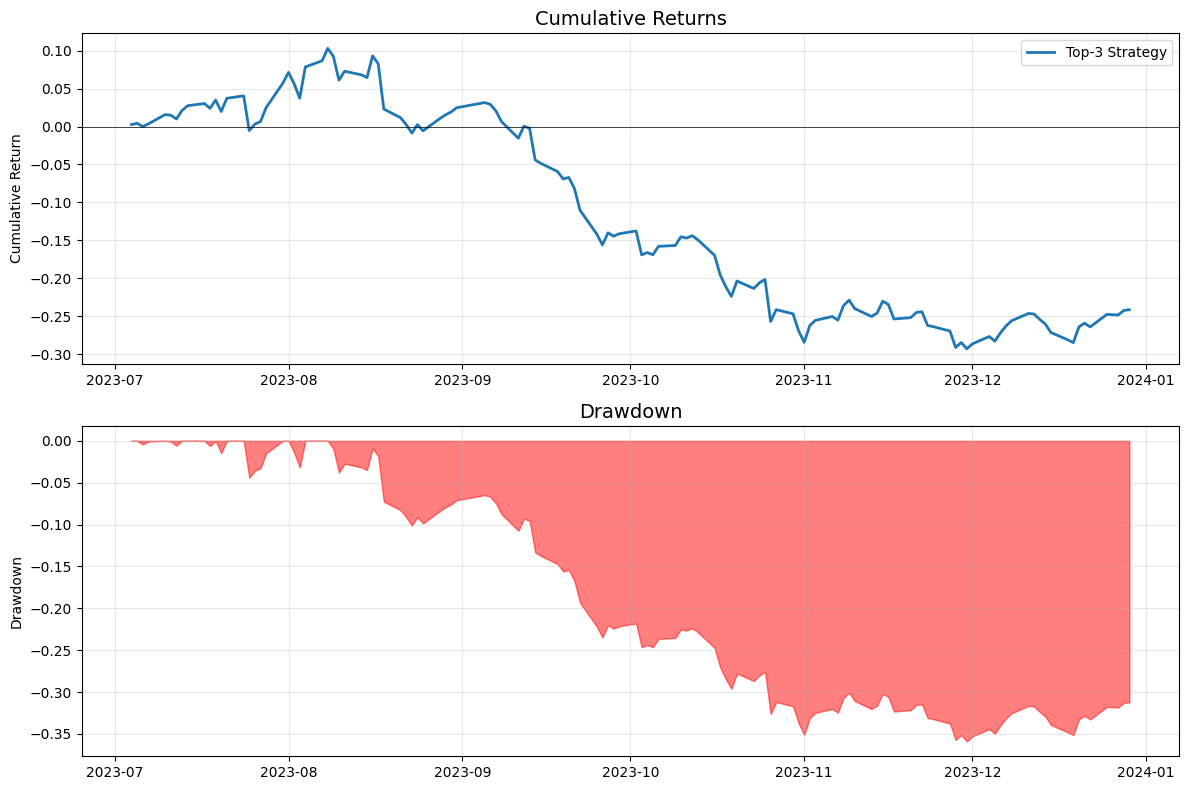

In [20]:
# Plot cumulative returns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Cumulative returns
cum_ret = (1 + portfolio_df['return']).cumprod() - 1
axes[0].plot(cum_ret.index, cum_ret.values, label=f'Top-{TOPK} Strategy', linewidth=2)
axes[0].set_title('Cumulative Returns', fontsize=14)
axes[0].set_ylabel('Cumulative Return')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# Drawdown
axes[1].fill_between(drawdown.index, drawdown.values, 0, alpha=0.5, color='red')
axes[1].set_title('Drawdown', fontsize=14)
axes[1].set_ylabel('Drawdown')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Feature Importance

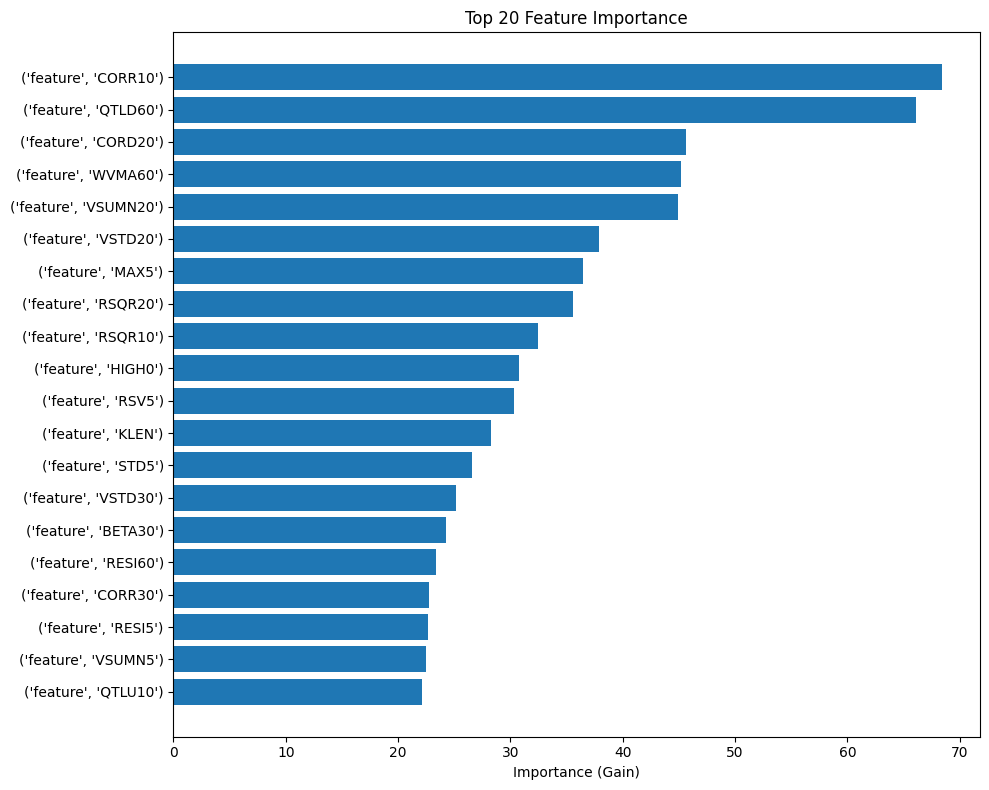


Top 10 Features:
           feature  importance
 (feature, CORR10)   68.391899
 (feature, QTLD60)   66.115820
 (feature, CORD20)   45.599400
 (feature, WVMA60)   45.196229
(feature, VSUMN20)   44.931200
 (feature, VSTD20)   37.875299
   (feature, MAX5)   36.480200
 (feature, RSQR20)   35.542100
 (feature, RSQR10)   32.481669
  (feature, HIGH0)   30.806280


In [22]:
# Get feature importance from LightGBM
try:
    # Try to get feature importance
    if hasattr(model, 'model') and model.model is not None:
        importance = model.model.feature_importance(importance_type='gain')
        
        # Get feature names from train_data (exclude label column)
        feature_cols = [col for col in train_data.columns if col != 'label']
        
        # Create DataFrame
        fi_df = pd.DataFrame({
            'feature': feature_cols[:len(importance)],
            'importance': importance
        }).sort_values('importance', ascending=False)
        
        # Plot top 20
        plt.figure(figsize=(10, 8))
        top_features = fi_df.head(20)
        plt.barh(range(len(top_features)), top_features['importance'].values)
        plt.yticks(range(len(top_features)), top_features['feature'].values)
        plt.xlabel('Importance (Gain)')
        plt.title('Top 20 Feature Importance')
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()
        
        print("\nTop 10 Features:")
        print(fi_df.head(10).to_string(index=False))
    else:
        print("Model not available")
except Exception as e:
    print(f"Could not get feature importance: {e}")

## 8. Quick Alternative: Using Custom Alpha Expressions

In [23]:
# Custom alpha factors using Qlib expressions
custom_fields = [
    # Momentum
    "Ref($close, -20) / $close - 1",           # 20-day return
    "Ref($close, -60) / $close - 1",           # 60-day return
    
    # Volume
    "Mean($volume, 5) / Mean($volume, 20)",    # Volume ratio
    "Std($volume, 20) / Mean($volume, 20)",    # Volume volatility
    
    # Price
    "($high - $low) / $close",                 # Daily range
    "($close - $open) / ($high - $low + 1e-8)", # Intraday momentum
    
    # Moving Averages
    "$close / Mean($close, 20) - 1",           # Price vs MA20
    "Mean($close, 5) / Mean($close, 20) - 1",  # MA5/MA20
    
    # RSI-like
    "Rank(Ref($close, -5) / $close - 1)",      # Rank of 5-day return
]

# Get custom features
custom_df = D.features(
    instruments='all',
    fields=custom_fields,
    start_time='2023-01-01',
    end_time='2023-12-31'
)

print(f"Custom features shape: {custom_df.shape}")
custom_df.head(10)

ValueError: Unsupported input type for param `instrument`

---
## Summary

**Qlib Workflow:**
1. `convert_csv_to_qlib()` - Convert CSV to Qlib binary format
2. `qlib.init()` - Initialize Qlib
3. `Alpha158` / `DatasetH` - Create features & dataset
4. `LGBModel.fit()` - Train model
5. `backtest_daily()` - Run backtest
6. `risk_analysis()` - Calculate metrics

**No need to write custom preprocessing or backtesting code!**